In [1]:
import torch
import random
from src.positional_encoding import PositionalEncoding
import matplotlib.pyplot as plt
from src.model import Model

In [2]:
class CircuitGenerator():
    def generate_circuit(self, n_qubits: int, n_gates: int):
        gate_dependancies = []
        for i in range(0, n_gates):
            q1 = random.randint(0, n_qubits - 1)
            q2 = random.randint(0, n_qubits - 1)
            while q1 == q2:
                q2 = random.randint(0, n_qubits - 1)
            gate_dependancies.append((q1, q2))
        return Circuit(n_qubits, gate_dependancies)
    
class Circuit:
    def __init__(self, n_qubits: int, gate_dependancies: list[tuple[int, int]]):
        self.n_qubits = n_qubits
        self.gate_dependancies = gate_dependancies
        
    def to_tensor(self, horizon=None, height=None):
        vectors = [self.get_vector(q1, q2) for q1, q2 in self.gate_dependancies]
        if horizon is not None:
            vectors = vectors[:horizon]
        
            
        tensor = torch.cat(vectors)
        return tensor
    
    def get_vector(self, q1, q2):
        """sum of onehot vectors for each of the two qubits"""
        I = torch.eye(self.n_qubits).view(1, self.n_qubits, self.n_qubits)
        return I[:,q1] + I[:,q2]
    

n_qubits = 6
positional_embedding = PositionalEncoding(6, dropout=0.0)



curcuit_generator = CircuitGenerator()
x = curcuit_generator.generate_circuit(6, 100).to_tensor()


print(x.shape)
print(x)


torch.Size([100, 6])
tensor([[0., 1., 0., 0., 1., 0.],
        [0., 1., 1., 0., 0., 0.],
        [0., 0., 0., 1., 1., 0.],
        [0., 1., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 1.],
        [0., 1., 0., 0., 1., 0.],
        [1., 0., 0., 0., 1., 0.],
        [1., 0., 0., 1., 0., 0.],
        [0., 0., 1., 1., 0., 0.],
        [0., 0., 1., 0., 1., 0.],
        [0., 1., 0., 0., 0., 1.],
        [0., 1., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0., 1.],
        [1., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 1.],
        [0., 1., 0., 0., 1., 0.],
        [0., 1., 0., 1., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1.],
        [1., 0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 1.],
        [1., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0., 1.],
        [0., 0., 1., 0., 1., 0.],
        [0., 0., 1., 0., 0., 1.],
        [1., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 1.

In [3]:
model = Model(n_qubits=6, length=100, n_gates=7)

In [6]:
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

821447


In [6]:
out.shape

torch.Size([100, 1, 512])

In [157]:
out = out.detach()

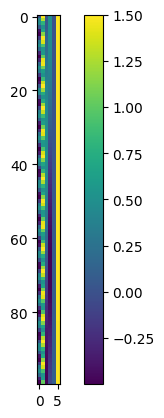

In [171]:
x1 = x*0
x1 = x + 0.5 * positional_embedding(x1)


plt.imshow(x1[:,0])
plt.colorbar()
plt.show()